# Swiggy/Zomato Delivery Analytics

Author: Neethu Raj P  
Tools Used: Pandas, Python, SQL, Excel

This project analyzes food delivery operations using Python (Pandas), SQL, and Excel dashboards.

The analysis focuses on:
- order trends
- delivery performance
- rider efficiency
- cancellation behavior
- distance-based operational insights

## Contents
1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Key Insights
7. Export Cleaned Dataset

# 1. Import Libraries
The required Python libraries are imported for data cleaning, analysis, and datetime operations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Dataset
The dataset is loaded into Pandas for preprocessing and exploratory analysis.

In [2]:
swiggy_zomato_order = pd.read_csv("Swiggy Zomato Order Information.csv")

# 3. Data Cleaning
Data cleaning is performed to improve data quality and ensure accurate analysis. This includes 
- handling duplicates
- checking missing values
- converting columns into appropriate data types.

##  Remove Duplicates

In [3]:
swiggy_zomato_order = swiggy_zomato_order.drop_duplicates()

## Convert Text to Datetime
Datetime columns are converted into proper datetime format to enable time-based analysis such as hourly and daily trends.


In [4]:
date_columns = ['order_time','order_date','allot_time','accept_time','pickup_time','delivered_time','cancelled_time']

In [5]:
swiggy_zomato_order[date_columns] = swiggy_zomato_order[date_columns].apply(
    lambda col: pd.to_datetime(col, errors='coerce')
)

C:\Users\user\AppData\Local\Temp\ipykernel_16588\6402075.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  lambda col: pd.to_datetime(col, errors='coerce')
C:\Users\user\AppData\Local\Temp\ipykernel_16588\6402075.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  lambda col: pd.to_datetime(col, errors='coerce')
C:\Users\user\AppData\Local\Temp\ipykernel_16588\6402075.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  lambda col: pd.to_datetime(col, errors='coerce')
C:\Users\user\AppData\Local\Temp\ipykernel_16588\6402075.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was spec

## Check Missing Values

In [6]:
swiggy_zomato_order = swiggy_zomato_order.dropna(subset=['order_time'])

# 4. Feature Engineering

New features are created from existing columns to support operational analysis and KPI tracking. These features help identify delivery trends, rider performance, and time-based patterns.
  1. delivery_minutes
  2. order_hour

##  Delivery Time Calculation
Delivery duration is calculated to measure operational efficiency and analyze rider performance.

In [7]:
swiggy_zomato_order['delivery_minutes'] = (
    (swiggy_zomato_order['delivered_time'] - swiggy_zomato_order['allot_time'])
    .dt.total_seconds() / 60
)

##  Order Hour Extraction
Order hour is extracted from timestamps to analyze peak demand periods throughout the day.

In [8]:
swiggy_zomato_order['order_hour'] = swiggy_zomato_order['order_time'].dt.hour

##  Distance Calculation

In [9]:
swiggy_zomato_order["distance"] = swiggy_zomato_order["first_mile_distance"] + swiggy_zomato_order["last_mile_distance"]

##  Distance Bucket Creation

In [10]:
swiggy_zomato_order["distance_bucket"] = "0-2 km"
swiggy_zomato_order.loc[(swiggy_zomato_order["distance"] > 2) & (swiggy_zomato_order["distance"] <= 5),"distance_bucket"] = "2-5 km"
swiggy_zomato_order.loc[(swiggy_zomato_order["distance"] > 5) & (swiggy_zomato_order["distance"] <= 8),"distance_bucket"] = "5-8 km"
swiggy_zomato_order.loc[(swiggy_zomato_order["distance"] > 8) & (swiggy_zomato_order["distance"] <= 15),"distance_bucket"] = "8-15 km"
swiggy_zomato_order.loc[swiggy_zomato_order["distance"] > 16,"distance_bucket"] = "> 15 km"

In [11]:
swiggy_zomato_order.head()

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,...,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time,delivery_minutes,order_hour,distance,distance_bucket
0,2021-01-26 02:21:00,556753,2021-01-26,2021-01-26 02:21:00,2021-01-26 02:22:00,2021-01-26 02:32:00,2021-01-26 02:49:00,11696,1.5666,2.65,...,621.0,NaN,NaN,NaN,NaN,NaT,28.0,2,4.2166,2-5 km
1,2021-01-26 02:33:00,556754,2021-01-26,2021-01-26 02:33:00,2021-01-26 02:34:00,2021-01-26 02:50:00,2021-01-26 03:11:00,18117,2.5207,2.76,...,105.0,NaN,NaN,NaN,3.266667,NaT,38.0,2,5.2807,5-8 km
2,2021-01-26 02:39:00,556755,2021-01-26,2021-01-26 02:39:00,2021-01-26 02:40:00,2021-01-26 02:56:00,2021-01-26 03:12:00,18623,2.2074,4.80,...,66.0,NaN,NaN,NaN,9.816667,NaT,33.0,2,7.0074,5-8 km
3,2021-01-26 02:47:00,556756,2021-01-26,2021-01-26 02:48:00,2021-01-26 02:49:00,2021-01-26 03:21:00,2021-01-26 03:41:00,15945,2.1894,6.38,...,127.0,NaN,NaN,NaN,17.533333,NaT,53.0,2,8.5694,8-15 km
4,2021-01-26 03:06:00,556757,2021-01-26,2021-01-26 03:07:00,2021-01-26 03:07:00,2021-01-26 03:31:00,2021-01-26 04:00:00,17589,2.7870,4.01,...,84.0,NaN,NaN,NaN,1.350000,NaT,53.0,3,6.7970,5-8 km


# 5. Exploratory Data Analysis
Exploratory analysis is performed to identify trends, patterns, and operational insights from the delivery dataset.

## 5.1   Rider Performance Analysis

Rider performance analysis helps identify delivery efficiency variations among riders based on delivery duration and workload..

### Rider Efficiency Table

Create a rider efficiency table containing total orders, delivered orders, cancellations, average delivery time, and cancellation rate for each rider.

In [12]:
rider_efficiency = swiggy_zomato_order.groupby('rider_id').agg(
    total_orders=('order_id', 'count'),
    delivered_orders=('delivered_time', 'count'), 
    total_cancelled=('cancelled', 'sum'),
    avg_delivery_time=('delivery_minutes', 'mean'),
    cancellation_rate=('cancelled', lambda x: round(x.mean() * 100, 2))
)

In [13]:
rider_efficiency = rider_efficiency.reset_index()

Round average delivery time to 2 decimal places.

In [14]:
rider_efficiency['avg_delivery_time'] = rider_efficiency['avg_delivery_time'].round(2)

Create a new column 'rider_category' to analyze rider performance based on avg_delivery_time.

In [15]:
def categorize_rider(order):
    if pd.isna(order['avg_delivery_time']):
        return 'No Delivery'
    if order['avg_delivery_time'] <= 20 and order['cancellation_rate'] < 5:
        return 'Top Performer'
    if order['avg_delivery_time'] <= 30:
        return 'Average Performer'
    return 'Poor Performer'

rider_efficiency['rider_category'] = rider_efficiency.apply(categorize_rider, axis=1)

In [16]:
rider_efficiency

,rider_id,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate,rider_category
0,0,7,6,1,20.33,14.29,Average Performer
1,1,16,16,0,27.88,0.00,Average Performer
2,2,28,28,0,24.75,0.00,Average Performer
3,4,3,3,0,33.33,0.00,Poor Performer
4,5,19,19,0,32.68,0.00,Poor Performer
...,...,...,...,...,...,...,...
19532,21562,1,0,1,NaN,100.00,No Delivery
19533,21563,1,1,0,58.00,0.00,Poor Performer
19534,21564,1,0,1,NaN,100.00,No Delivery
19535,21565,1,1,0,37.00,0.00,Poor Performer


### Top 10 Riders

Create table top riders

In [17]:
def top_10_riders(df):

    top = df[
        (df['rider_category'] == 'Top Performer') &
        (df['total_orders'] >= 10)
    ].copy()

    top = top.sort_values(
        by=['avg_delivery_time', 'cancellation_rate'],
        ascending=[True, True]
    )

    top['Rank'] = range(1, len(top) + 1)

    return top.head(10)

top_riders = top_10_riders(rider_efficiency)

In [18]:
top_riders

,rider_id,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate,rider_category,Rank
1133,1278,17,17,0,14.06,0.00,Top Performer,1
148,173,64,63,1,15.60,1.56,Top Performer,2
10810,12692,13,13,0,16.08,0.00,Top Performer,3
158,185,38,38,0,16.13,0.00,Top Performer,4
11478,13392,16,16,0,16.25,0.00,Top Performer,5
9510,11150,12,12,0,16.50,0.00,Top Performer,6
422,478,83,83,0,16.53,0.00,Top Performer,7
1658,1891,24,24,0,16.58,0.00,Top Performer,8
9651,11304,13,13,0,16.77,0.00,Top Performer,9
14858,16888,20,20,0,16.80,0.00,Top Performer,10


Certain riders consistently achieve lower delivery times, indicating higher operational efficiency.

###  Worst 10 riders 

In [19]:
worst_riders = rider_efficiency[
    (rider_efficiency['avg_delivery_time'] > 30) &
    (rider_efficiency['total_orders'] >= 10) &
    (rider_efficiency['cancellation_rate'] > 10)
].copy()

worst_riders = worst_riders.sort_values(
    by=['avg_delivery_time', 'cancellation_rate'],
    ascending=[False, False]
)

worst_riders.head(10)

,rider_id,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate,rider_category
3856,4463,13,11,2,162.45,15.38,Poor Performer
15901,17931,11,9,2,143.00,18.18,Poor Performer
14730,16760,11,9,2,135.78,18.18,Poor Performer
18041,20071,12,10,2,114.50,16.67,Poor Performer
7306,8474,13,10,3,75.40,23.08,Poor Performer
12990,15020,20,17,3,69.88,15.00,Poor Performer
14393,16423,18,16,2,61.00,11.11,Poor Performer
2115,2413,28,25,3,58.48,10.71,Poor Performer
16897,18927,11,7,4,57.00,36.36,Poor Performer
17078,19108,11,9,2,54.56,18.18,Poor Performer


Some riders experience significantly higher delivery times, which may indicate operational challenges or route inefficiencies.

## 5.2 Late Delivery Analysis

Late delivery percentage is analyzed to measure service reliability and identify operational inefficiencies.


### Late Delivery Percentage

In [20]:
def late_delivery_percentage(df):

    df = df.copy()

    df['is_late'] = (
        (df['delivery_minutes'] > 30) &
        (df['delivered_time'].notna())
    )

    late_deliveries = df.groupby('rider_id').agg(
        delivered_orders=('delivered_time', 'count'),
        late_orders=('is_late', 'sum')
    )

    late_matrix = late_deliveries[
        late_deliveries['delivered_orders'] > 10
    ].copy()

    late_matrix['late_delivery_percentage'] = (
        late_matrix['late_orders'] * 100 /
        late_matrix['delivered_orders']
    ).round(2)

    late_matrix['rank'] = (
        late_matrix['late_delivery_percentage']
        .rank(method='dense', ascending=False)
    )

    return late_matrix.sort_values(
        by='late_delivery_percentage',
        ascending=False
    )


late_delivery_rider = late_delivery_percentage(swiggy_zomato_order)
  

In [21]:
late_delivery_rider

,delivered_orders,late_orders,late_delivery_percentage,rank
rider_id,,,,
7489,14,14,100.0,1.0
1385,28,28,100.0,1.0
17729,11,11,100.0,1.0
20336,12,12,100.0,1.0
19404,13,13,100.0,1.0
...,...,...,...,...
14844,14,0,0.0,1590.0
3919,14,0,0.0,1590.0
10440,22,0,0.0,1590.0


A noticeable percentage of deliveries are delayed, indicating opportunities for improving operational planning and rider allocation.

## 5.3 Rider Productivity Analysis

### Orders Per Rider Analysis

Orders per rider are analyzed to understand workload distribution and rider productivity across operational periods.

In [22]:
order_per_rider_per_day = (
    swiggy_zomato_order
    .groupby(['rider_id','order_date'])
    .agg(total_orders = ('order_id','count'))
    .sort_values(['rider_id','order_date'])).reset_index()
order_per_rider_per_day

,rider_id,order_date,total_orders
0,0,2021-01-27,1
1,0,2021-01-29,2
2,0,2021-02-01,3
3,0,2021-02-04,1
4,1,2021-02-03,7
...,...,...,...
94615,21562,2021-01-26,1
94616,21563,2021-01-26,1
94617,21564,2021-01-26,1
94618,21565,2021-01-26,1


###  Average Daily Orders Per Rider

Average daily orders per rider are calculated to evaluate rider productivity and delivery efficiency.

In [23]:
avg_daily_order_per_rider = (
    swiggy_zomato_order
    .groupby('rider_id')
    .agg(
        total_orders=('order_id', 'count'),
        avg_daily_orders=(
            'order_date',
            lambda x: round(len(x) / x.nunique(), 2)
        )
    )
)

avg_daily_order_per_rider = (
    avg_daily_order_per_rider[
        avg_daily_order_per_rider['total_orders'] >= 10
    ]
    .sort_values(
        by='avg_daily_orders',
        ascending=False
    )
    .drop(columns='total_orders')
    .reset_index()
)

avg_daily_order_per_rider

,rider_id,avg_daily_orders
0,18123,22.00
1,384,19.83
2,237,19.00
3,170,18.45
4,20522,18.00
...,...,...
11576,3483,1.25
11577,2136,1.22
11578,7510,1.22
11579,6111,1.18


Average daily order distribution provides insight into rider utilization and operational capacity management.

## 5.4 Hourly Operational Analysis

Hourly operational KPIs are calculated to analyze customer demand patterns, delivery efficiency, and cancellation behavior throughout the day.

### Hourly KPI Table

In [24]:
order_hour_table = swiggy_zomato_order.groupby('order_hour').agg(
    total_orders=('order_id', 'count'),
    delivered_orders=('delivered_time', 'count'), 
    total_cancelled=('cancelled', 'sum'),
    avg_delivery_time=('delivery_minutes', 'mean'),
    cancellation_rate=('cancelled', lambda x: round(x.mean() * 100, 2))
).reset_index()

In [25]:
order_hour_table["avg_delivery_time"] = order_hour_table["avg_delivery_time"].round(2)

In [26]:
order_hour_table.head()

,order_hour,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate
0,0,2,2,0,32.50,0.00
1,1,2,2,0,36.00,0.00
2,2,61,59,2,27.42,3.28
3,3,645,636,9,32.60,1.40
4,4,1211,1200,11,31.37,0.91


The hourly KPI table helps identify peak operational periods, service delays, and customer demand fluctuations across different hours.

### Peak Demand Hours

Peak demand hours are identified to understand customer ordering behavior and operational workload distribution.

In [27]:
peak_hours = order_hour_table.sort_values(
    by='total_orders',
    ascending=False
).head(5)

peak_hours

,order_hour,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate
14,14,70587,69620,967,34.99,1.37
16,16,66326,65582,744,29.15,1.12
15,15,66183,65483,700,30.70,1.06
17,17,53648,52892,756,29.12,1.41
13,13,43407,42947,460,33.98,1.06


The results indicate that customer demand is concentrated during afternoon and evening periods, increasing operational workload during these hours.

### Highest Cancellation Hours

Cancellation trends are analyzed to identify operational stress periods and potential service inefficiencies.

In [28]:
high_cancel_hours = order_hour_table.sort_values(
    by='cancellation_rate',
    ascending=False
).head(5)

high_cancel_hours

,order_hour,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate
20,20,8,7,1,25.57,12.50
19,19,25,24,1,28.42,4.00
2,2,61,59,2,27.42,3.28
18,18,168,164,4,30.28,2.38
5,5,1089,1072,17,32.44,1.56


Higher cancellation rates during certain hours may indicate rider shortages, delayed deliveries, or increased operational pressure.

### Slowest Delivery Hours

Average delivery time is analyzed across different hours to identify periods with reduced operational efficiency.

In [29]:
slow_delivery_hours = order_hour_table.sort_values(
    by='avg_delivery_time',
    ascending=False
).head(5)

slow_delivery_hours

,order_hour,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate
21,21,2,2,0,38.50,0.00
1,1,2,2,0,36.00,0.00
14,14,70587,69620,967,34.99,1.37
13,13,43407,42947,460,33.98,1.06
3,3,645,636,9,32.60,1.40


Longer delivery durations during peak periods suggest increased rider workload and operational congestion.

## 5.5 Distance Analysis

Distance analysis is performed to evaluate how delivery distance impacts delivery duration and operational efficiency.

### Distance KPI Table

In [30]:
order_distance_table = swiggy_zomato_order.groupby('distance_bucket').agg(
    total_orders=('order_id', 'count'),
    delivered_orders=('delivered_time', 'count'), 
    total_cancelled=('cancelled', 'sum'),
    avg_delivery_time=('delivery_minutes', 'mean'),
    cancellation_rate=('cancelled', lambda x: round(x.mean() * 100, 2))
).reset_index()

In [31]:
order_distance_table

,distance_bucket,total_orders,delivered_orders,total_cancelled,avg_delivery_time,cancellation_rate
0,0-2 km,73807,73093,714,25.742985,0.97
1,2-5 km,226170,223784,2386,30.357814,1.05
2,5-8 km,127596,125864,1732,34.882341,1.36
3,8-15 km,22385,22002,383,39.323789,1.71
4,> 15 km,41,39,2,42.666667,4.88


The distance analysis table highlights the relationship between delivery distance, operational efficiency, and cancellation behavior.

The following visualizations help compare operational KPIs across different delivery distance ranges.

Text(0.5, 0, 'Distance Bucket')

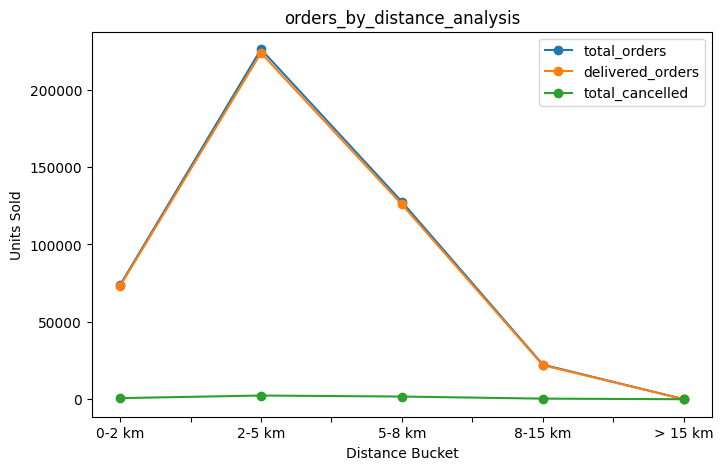

In [32]:
order_distance_table.plot(
    x = 'distance_bucket',
    y = ["total_orders","delivered_orders","total_cancelled"],
    kind = 'line',
    marker = 'o',
    figsize=(8, 5),
    title='orders_by_distance_analysis')
plt.ylabel('Units Sold')
plt.xlabel('Distance Bucket')

Text(0.5, 0, 'Distance Bucket')

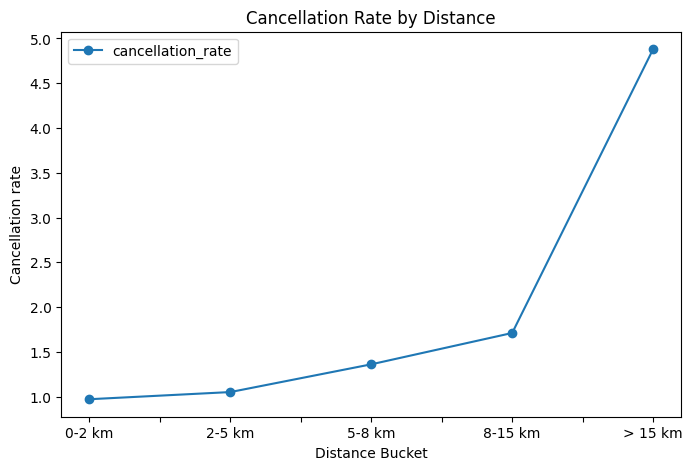

In [33]:
order_distance_table.plot(
    x = 'distance_bucket',
    y = ["cancellation_rate"],
    kind = 'line',
    marker = 'o',
    figsize=(8, 5),
    title='Cancellation Rate by Distance')
plt.ylabel('Cancellation rate')
plt.xlabel('Distance Bucket')

Text(0.5, 0, 'Distance Bucket')

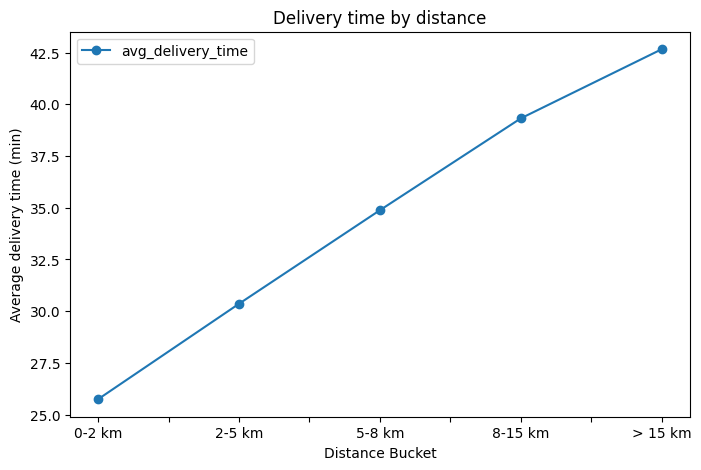

In [34]:
order_distance_table.plot(
    x = 'distance_bucket',
    y = ["avg_delivery_time"],
    kind = 'line',
    marker = 'o',
    figsize=(8, 5),
    title='Delivery time by distance')
plt.ylabel('Average delivery time (min)')
plt.xlabel('Distance Bucket')

Delivery time increases progressively with distance, highlighting the operational impact of long-distance deliveries.

# 6. Key Insights

- Peak order demand occurs during afternoon and evening hours.
- Longer delivery distances increase delivery time significantly.
- Certain riders consistently outperform others in efficiency.
- Rider workload varies considerably across different days.
- Delivery completion percentage indicates overall operational efficiency.

#  7. Business Recommendations
- Increase rider allocation during peak demand hours.
- Monitor long-distance deliveries to reduce delays.
- Investigate causes of higher cancellations during busy periods.
- Reward consistently efficient riders.
- A noticeable percentage of orders experience delayed delivery, indicating potential operational bottlenecks during peak periods.

# 8. Conclusion

This project analyzed food delivery operations using Pandas, SQL, and Excel dashboards to identify operational trends, rider efficiency, delivery delays, and customer demand patterns. The analysis provides business insights that can support operational optimization and service improvement.

# 9. Export Cleaned Dataset

The cleaned and transformed dataset is exported for dashboard creation and further business analysis.

In [35]:
swiggy_zomato_order.to_csv(
    'cleaned_swiggy_zomato_orders.csv',
    index=False
)